In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
import joblib


In [ ]:
file = "../Vascular epiphyte global distributions/database.xlsx"
region_climate = pd.read_excel(file, sheet_name=4)
epi_richness = pd.read_excel(file, sheet_name=3)


,link_ID,geo_entity,confidence_GIFT/WCSP,confidence_Hassler,biome,longitude,latitude,lat_absolute,hemisphere,kingdom_WWF,...,TF_current,TF_LGM,prec,PrecSeas,temp_mean,ElevRange,LGM_ice,vascular_total,ferns_total,seeds_total
0,AFG,Afghanistan,1,1,Deserts & Xeric Shrublands,66.026539,33.838903,33.838903,north,Indomalayan,...,0.000000e+00,0.00000,1521.0,137.0,13.07694,6291,1.889531e+04,4592.0,54.0,4545.0
1,ALA,Alabama,1,1,"Temperate Grasslands, Savannas & Shrublands",-86.829068,32.793899,32.793899,north,Nearctic,...,0.000000e+00,0.00000,1828.0,29.0,17.53835,586,0.000000e+00,3308.0,129.0,3178.0
2,ASK,Alaska,1,1,Tundra,-152.471187,64.305012,64.305012,north,Nearctic,...,0.000000e+00,0.00000,6370.0,133.0,-4.14852,6071,9.243467e+05,1533.0,89.0,1441.0
3,ALB,Albania,1,1,"Mediterranean Forests, Woodlands & Scrub",20.068372,41.142546,41.142546,north,Palearctic,...,0.000000e+00,0.00000,2666.0,71.0,12.01210,2346,8.523476e+02,3393.0,56.0,3340.0
4,ABT,Alberta,1,1,Boreal Forests/Taiga,-114.510959,55.168472,55.168472,north,Nearctic,...,0.000000e+00,0.00000,1198.0,78.0,1.60110,3140,1.322881e+06,1782.0,80.0,1693.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,YUG,Yugoslavia,1,1,Temperate Broadleaf & Mixed Forests,18.724339,44.160241,44.160241,north,Palearctic,...,0.000000e+00,0.00000,3185.0,53.0,10.55333,2451,5.964090e+02,5314.0,102.0,5219.0
269,YUK,Yukon,1,1,Tundra,-135.498148,63.635750,63.635750,north,Nearctic,...,0.000000e+00,0.00000,4463.0,118.0,-4.93015,5700,6.097876e+05,1201.0,50.0,1138.0
270,ZAI,Za?re,1,0,"Tropical & Subtropical Grasslands, Savannas & ...",23.654457,-2.876231,2.876231,south,Afrotropic,...,1.135216e+06,25232.00697,3299.0,124.0,22.92848,4327,0.000000e+00,9218.0,NaN,8984.0
271,ZAM,Zambia,1,1,"Tropical & Subtropical Grasslands, Savannas & ...",27.797881,-13.453079,13.453079,south,Afrotropic,...,3.497111e+04,0.00000,1941.0,135.0,21.42857,1842,0.000000e+00,5572.0,185.0,5390.0


In [132]:
region_climate = region_climate[
	[
		'link_ID',
		'biome',
		'lat_absolute',
		'kingdom_WWF',
		'prec',
		'PrecSeas',
		'temp_mean',
		'ElevRange'
	]
]
epi_richness = epi_richness[
	[
		'link_ID',
		'epi_total',
		'epi_ferns',
		'epi_seeds'
	]
]
epi_region = pd.merge(
    region_climate,
    epi_richness,
    on="link_ID",
    how="inner"
)

In [133]:
epi_region["epi_score"] = (
    epi_region["epi_total"].rank(pct=True)
)

epi_region["fern_score"] = (
    epi_region["epi_ferns"].rank(pct=True)
)

epi_region["seed_score"] = (
    epi_region["epi_seeds"].rank(pct=True)
)

In [ ]:
X = epi_region[
    [
		"lat_absolute",
        "prec",
        "PrecSeas",
        "temp_mean",
        "ElevRange"
    ]
]

categorical = []

numeric = [
	"lat_absolute",
    "prec",
    "PrecSeas",
    "temp_mean",
    "ElevRange"
]

y = epi_region["epi_score"]

In [ ]:
preprocessor = ColumnTransformer(
    [
        (
            "num",
            "passthrough",
            numeric
        )
    ]
)

In [136]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [137]:
model = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ))
])

model.fit(X_train, y_train)

,steps,"[('prep', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [138]:
cv = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

cv_pred = cross_val_predict(
    model,
    X,
    y,
    cv=5
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print("Mean R²:", scores.mean())
print("Std:", scores.std())

Mean R²: 0.8558639100070016
Std: 0.03322496873996315


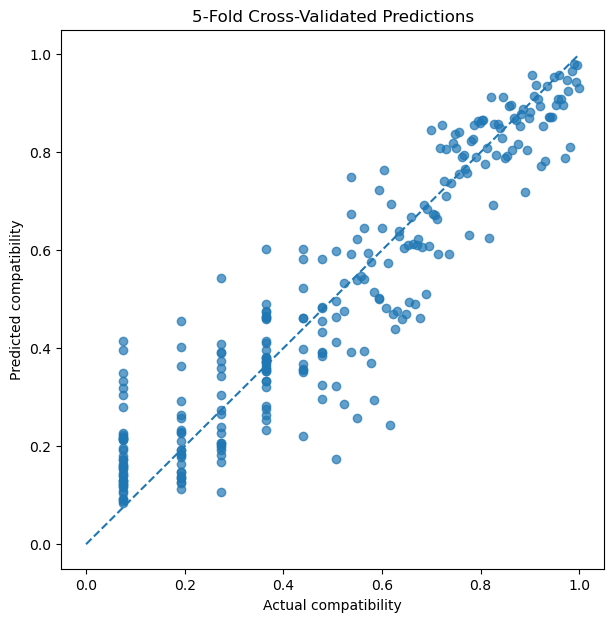

In [139]:
plt.figure(figsize=(7,7))

plt.scatter(
    y,
    cv_pred,
    alpha=0.7
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Actual compatibility")
plt.ylabel("Predicted compatibility")
plt.title("5-Fold Cross-Validated Predictions")

plt.show()

In [140]:
rf = model.named_steps["rf"]

feature_names = (
    model.named_steps["prep"]
         .get_feature_names_out()
)

importances = rf.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

importance_df.head(15)

,feature,importance
1,num__prec,0.527271
0,num__lat_absolute,0.374362
2,num__PrecSeas,0.039815
4,num__ElevRange,0.031782
3,num__temp_mean,0.026770


In [141]:
model.fit(X, y)
joblib.dump(model, "../epiphyte_suitability.pkl")

['../epiphyte_suitability.pkl']